In [1]:
import sys

# sanity check: print path to the Python binary, verify Python version
print(sys.executable, sys.version_info)
assert sys.version_info.major == 3 and sys.version_info.minor == 12, "Python version does not match the expected version."

/data/jhehli/conda/envs/env3.12/bin/python sys.version_info(major=3, minor=12, micro=12, releaselevel='final', serial=0)


In [11]:
from huggingface_hub import login
login()

In [7]:
import os

import matplotlib.pyplot as plt
import numpy as np

import sam3
from PIL import Image
from sam3 import build_sam3_image_model
from sam3.model.box_ops import box_xywh_to_cxcywh
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.visualization_utils import draw_box_on_image, normalize_bbox, plot_results

sam3_root = os.path.join(os.path.dirname(sam3.__file__), "..")

In [8]:
import torch

# turn on tfloat32 for Ampere GPUs
# https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# use bfloat16 for the entire notebook
torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

In [ ]:
bpe_path = f"{sam3_root}/assets/bpe_simple_vocab_16e6.txt.gz"
model = build_sam3_image_model(bpe_path=bpe_path)

config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

sam3.pt:   0%|          | 0.00/3.45G [00:00<?, ?B/s]

In [31]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"SAM3 total parameters: {total_params}")
print(f"SAM3 trainable parameters: {trainable_params} \n")

SAM3 total parameters: 840509750
SAM3 trainable parameters: 840509750 



In [32]:
device = torch.device("cuda:0")
total_memory = torch.cuda.get_device_properties(device).total_memory
print(f"GPU total memory: {total_memory / (1024**3):.2f} GB")

GPU total memory: 23.56 GB


In [48]:
def zeroshot_segmentation_textprompt(image_path, prompt="lines"):
    image = Image.open(image_path).resize((512, 512))

    processor = Sam3Processor(model, confidence_threshold=0.5)
    inference_state = processor.set_image(image)

    processor.reset_all_prompts(inference_state)
    inference_state = processor.set_text_prompt(state=inference_state, prompt=prompt)

    # convert image (for plotting) to 512x512 RGB (RGB (3 channels) conversion needed because otherwise will look green in plot)
    img0 = Image.open(image_path).resize((512, 512)).convert("RGB")
    plot_results(img0, inference_state)

found 22 object(s)


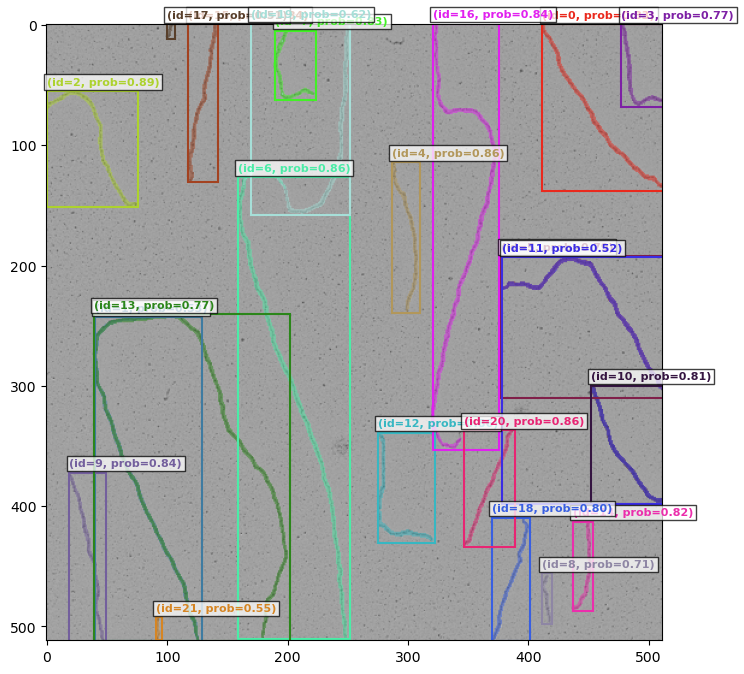

In [49]:
zeroshot_segmentation_textprompt('/data/jhehli/png_images/20250811_Dani_Vegetariana_Site of interest (2)_Bottom.png')

found 0 object(s)


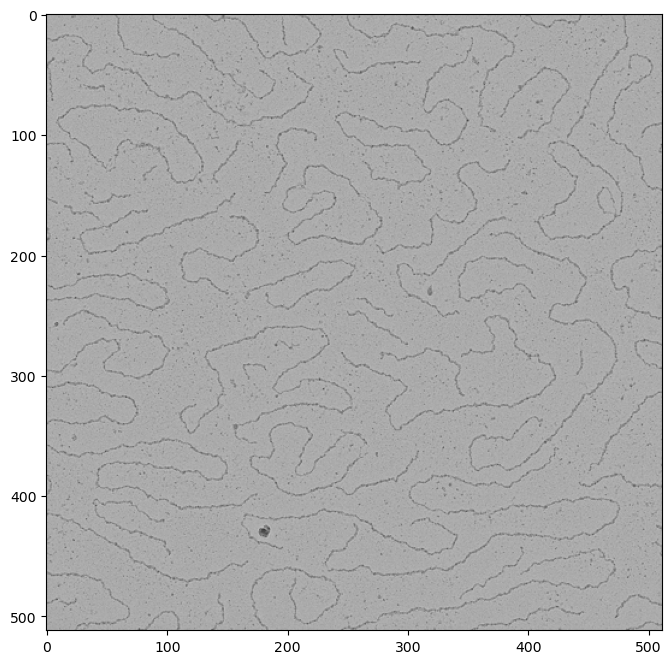

In [57]:
zeroshot_segmentation_textprompt('/data/jhehli/png_images/20240425_Andrea_lila_Site of interest (2)_Bottom.png')